In [ ]:
#I used AI to help me with the syntax for code, and to help me understand results,
#and the questions better. And, to verify the correctness of my work.


1.
1.1
  p = 1*p + 0*(1-p) = p = E(X)
  => estimator p_hat: X_bar =  1/n * sum(X_i, i, n)
  we select a sample propety. in this case the mean for the estimator as it's the only one that isolates p directly without extra parameters.
1.2
  Bernoulli var = p(1-p)
  sample_var = p_hat(1-p_hat)
  sample_std = sqrt(sample_var)
  standard_error = sample_std/sqrt(n)
  => sqrt(p_hat(1-p_hat))/sqrt(n)
  => sqrt(p_hat(1-p_hat)/n)

  var(p_hat) = var(1/n*sum(X_i, i, n)
  => 1/n^2 * var(sum(X_i, i, n)) #Var(aX) = a^2Var(X)
  => 1/n^2 * sum(var(X_i), i, n)) #Cov = 0, var of sum of independent rand vars = sum of individual vars
  => sum(var(X_i), i, n)) = p_hat(1-p_hat)+ p_hat(1-p_hat)+...p_hat(1-p_hat) = n*p_hat(1-p_hat)
  => 1/n^2 * n*p_hat(1-p_hat)
  => n*p_hat(1-p_hat)/n^2
  => var = p_hat(1-p_hat)/n


Personal notes:
- The mean is a weighted average based on probabilities, $$E[X] = \sum x_i \cdot P(X = x_i)$$ which is also the original mean formula. The usual one of values over N is a special case for equal probability versions.
- $\text{Var}(X_i) = E[X_i^2] - (E[X_i])^2$ makes sense if we consider  and 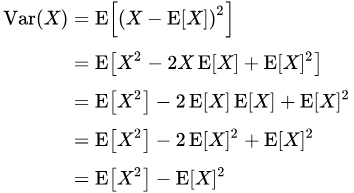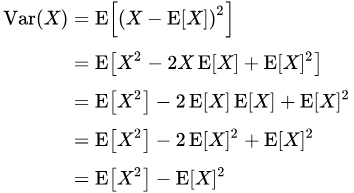
- 

Expected Value & Estimator$$p = 1 \cdot p + 0 \cdot (1 - p) = p = \mathbb{E}(X)$$$\Rightarrow$ estimator $\hat{p}$:$$\bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i$$We select a sample property (in this case, the sample mean $\bar{X}$) for the estimator as it is the only one that isolates $p$ directly without extra parameters.1.2 Variance, Standard Error, and Estimator VarianceBernoulli Variance: $\text{Var}(X) = p(1 - p)$Sample Variance: $\widehat{\text{Var}}(X) = \hat{p}(1 - \hat{p})$Sample Standard Deviation: $s = \sqrt{\hat{p}(1 - \hat{p})}$Standard Error:$$\text{SE} = \frac{s}{\sqrt{n}} \Rightarrow \frac{\sqrt{\hat{p}(1 - \hat{p})}}{\sqrt{n}} \Rightarrow \sqrt{\frac{\hat{p}(1 - \hat{p})}{n}}$$Derivation of $\text{Var}(\hat{p})$$$\text{Var}(\hat{p}) = \text{Var}\left(\frac{1}{n} \sum_{i=1}^{n} X_i\right)$$$$\Rightarrow \frac{1}{n^2} \text{Var}\left(\sum_{i=1}^{n} X_i\right) \quad \text{since } \text{Var}(aX) = a^2 \text{Var}(X)$$$$\Rightarrow \frac{1}{n^2} \sum_{i=1}^{n} \text{Var}(X_i) \quad \text{since } \text{Cov}(X_i, X_j) = 0 \text{ for independent variables}$$$$\Rightarrow \sum_{i=1}^{n} \text{Var}(X_i) = \hat{p}(1 - \hat{p}) + \hat{p}(1 - \hat{p}) + \dots + \hat{p}(1 - \hat{p}) = n\hat{p}(1 - \hat{p})$$$$\Rightarrow \frac{1}{n^2} \cdot n\hat{p}(1 - \hat{p})$$$$\Rightarrow \frac{n\hat{p}(1 - \hat{p})}{n^2}$$$$\Rightarrow \text{Var}(\hat{p}) = \frac{\hat{p}(1 - \hat{p})}{n}$$

(Computer Exercise) In this exercise we will study the correlation between cholesterol levels and presence of a heart disease using bootstrapping.

You can find a template python code for this exercise, as well as the data set from the Moodle folder titled ’ Week 2 - Exercise 2 template and data ’

Note: Report your answers to three significant digits.

    Compute the correlation coefficient between the cholesterol measurement and the presence of a heart disease (the chol and heart_disease variables in the provided template).

    Use bootstrapping with 10000
    resamples to form a standard error estimate for the correlation.

    Compute 95% bootstrap confidence intervals for the correlation using the Normal Interval, Percentile Interval and Pivotal Interval. Small numerical differences are expected due to the randomness.


In [8]:
import numpy as np
import pandas as pd
from scipy import stats


In [5]:
#2.

#2.1
# The data set is adapted from the UCI ML Repository
# Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). Heart Disease [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X.
# import dataset
data = pd.read_csv("ex2-template/week2_heart_disease_data.csv", index_col=0)

chol = data['chol']
heart_disease = 1 * (data['heart-disease'] != 0)
heart_disease, chol

(0      0
 1      1
 2      1
 3      0
 4      0
       ..
 298    1
 299    1
 300    1
 301    1
 302    0
 Name: heart-disease, Length: 303, dtype: int64,
 0      233
 1      286
 2      229
 3      250
 4      204
       ... 
 298    264
 299    193
 300    131
 301    236
 302    175
 Name: chol, Length: 303, dtype: int64)

In [72]:
#2.1 correlation coefficient for full data
correlation_coefficient = stats.pearsonr(chol, heart_disease)[0]
correlation_coefficient

np.float64(0.0851636113995313)

In [96]:
#10000 random samples with replacement
samples_to_take = np.shape(chol)[0] #(303,), same for heart_disease
boot_idxs = [np.random.choice(samples_to_take, size=samples_to_take, replace=True) for _ in range(0, 10000)]

chol_samples = [chol[idx] for idx in boot_idxs]
heart_disease_samples = [heart_disease[idx] for idx in boot_idxs]
# chol_samples = [chol.sample(n=chol_samples_to_take, replace=True) for _ in range (0, 10000)]
# heart_disease_samples_to_take = np.shape(heart_disease)[0] #(303,)
# heart_disease_samples = [heart_disease.sample(n=heart_disease_samples_to_take, replace=True) for _ in range (0, 10000)]
len(chol_samples), len(heart_disease_samples)

(10000, 10000)

In [97]:
#correlation coefficients
correlation_coefficients = [stats.pearsonr(chol_samples[i],heart_disease_samples[i])[0] \
                           for i in range(0, len(chol_samples)) \
                           ]

correlation_coefficients[:4]

[np.float64(0.21283692088012188),
 np.float64(-0.004809337803802499),
 np.float64(0.09977923755267093),
 np.float64(0.07079132834320827)]

In [ ]:
#2.2 standard error

In [98]:
std_err_corr_coef = np.std(correlation_coefficients, ddof=1)
std_err_corr_coef

np.float64(0.058715573373279636)

In [103]:
#2.3

#Normal interval
confidence_interval_normal = (correlation_coefficient - 1.96 * std_err_corr_coef, correlation_coefficient + 1.96 * std_err_corr_coef)

#Percentile interval
q_low, q_high = np.percentile(correlation_coefficients, [2.5, 97.5])
confidence_interval_percentile = (q_low, q_high)

#Pivotal interval
confidence_interval_pivotal = (2*correlation_coefficient - q_high, 2*correlation_coefficient - q_low)

confidence_interval_normal, confidence_interval_percentile, confidence_interval_pivotal

((np.float64(-0.029918912412096793), np.float64(0.2002461352111594)),
 (np.float64(-0.023872679105668152), np.float64(0.20531721452222207)),
 (np.float64(-0.034989991723159475), np.float64(0.19419990190473074)))

### personal notes:
- need to keep pairs intact for sampling by taking random indices, and then using the same idx for both at the same time.

- normal interval good when bootstrap looks close to a normal distribution
- percentile interval takes 95% middle (cuts off 2.5% on each side). 
- pivotal interval  measures drift from the og corr_coef. If drift one way, pivotal compensates

- observed line (corr_coeff) along the data would shift heavily to the right/left if there was a significant correlation

- confidence intervals would not cross 0 (neg or pos) if significant correlation.

- near 0 and crossing 0 -> no significant correlation (which is true in this case)

(array([  5.,   2.,   4.,   2.,   9.,  12.,  21.,  32.,  39.,  75., 107.,
        125., 158., 194., 309., 345., 410., 478., 481., 556., 562., 634.,
        621., 607., 559., 529., 494., 487., 414., 349., 286., 251., 217.,
        163., 125.,  94.,  63.,  59.,  35.,  35.,  19.,   9.,   6.,   7.,
          7.,   1.,   2.,   0.,   0.,   1.]),
 array([-0.11906094, -0.1100295 , -0.10099807, -0.09196663, -0.0829352 ,
        -0.07390376, -0.06487232, -0.05584089, -0.04680945, -0.03777802,
        -0.02874658, -0.01971515, -0.01068371, -0.00165228,  0.00737916,
         0.0164106 ,  0.02544203,  0.03447347,  0.0435049 ,  0.05253634,
         0.06156777,  0.07059921,  0.07963064,  0.08866208,  0.09769351,
         0.10672495,  0.11575639,  0.12478782,  0.13381926,  0.14285069,
         0.15188213,  0.16091356,  0.169945  ,  0.17897643,  0.18800787,
         0.19703931,  0.20607074,  0.21510218,  0.22413361,  0.23316505,
         0.24219648,  0.25122792,  0.26025935,  0.26929079,  0.27832222,
 

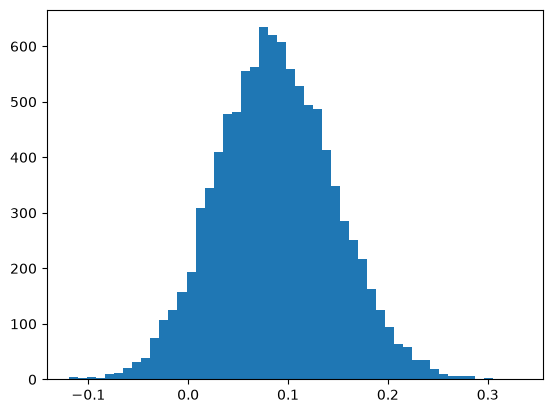

In [101]:
#plotting for the fun of it
import matplotlib.pyplot as plt
plt.hist(correlation_coefficients, bins=50)


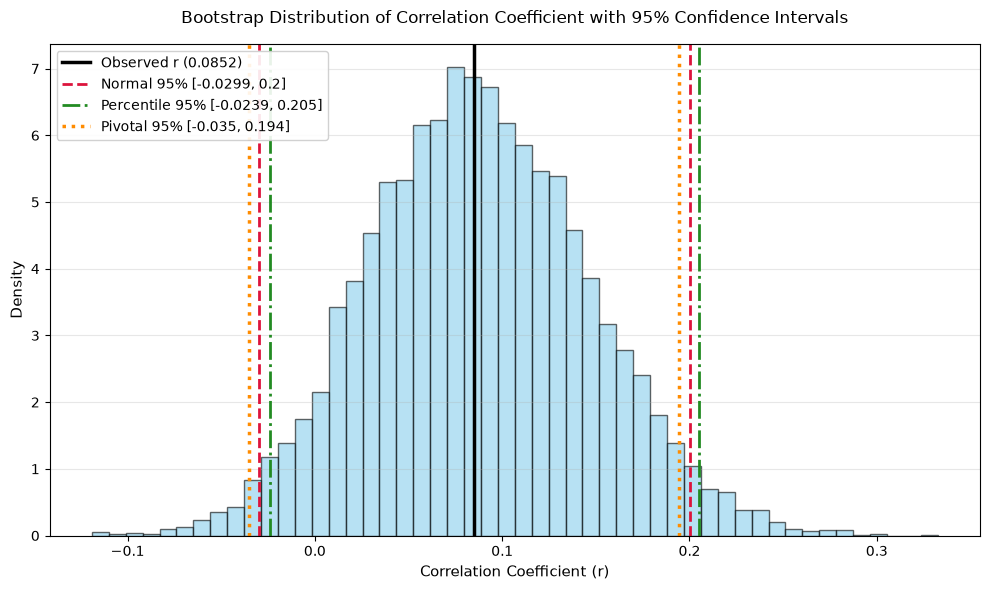

In [102]:
# 3. Plotting
plt.figure(figsize=(10, 6))

# Histogram of bootstrapped correlations
plt.hist(
    correlation_coefficients, bins=50, color="skyblue", edgecolor="black", alpha=0.6, density=True
)

# Reference line for r_obs
plt.axvline(
    correlation_coefficient,
    color="black",
    linestyle="-",
    linewidth=2.5,
    label=f"Observed r ({correlation_coefficient:.3g})",
)

# Normal Interval Lines
plt.axvline(
    confidence_interval_normal[0],
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Normal 95% [{confidence_interval_normal[0]:.3g}, {confidence_interval_normal[1]:.3g}]",
)
plt.axvline(confidence_interval_normal[1], color="crimson", linestyle="--", linewidth=2)

# Percentile Interval Lines
plt.axvline(
    confidence_interval_percentile[0],
    color="forestgreen",
    linestyle="-.",
    linewidth=2,
    label=f"Percentile 95% [{confidence_interval_percentile[0]:.3g}, {confidence_interval_percentile[1]:.3g}]",
)
plt.axvline(confidence_interval_percentile[1], color="forestgreen", linestyle="-.", linewidth=2)

# Pivotal Interval Lines
plt.axvline(
    confidence_interval_pivotal[0],
    color="darkorange",
    linestyle=":",
    linewidth=2.5,
    label=f"Pivotal 95% [{confidence_interval_pivotal[0]:.3g}, {confidence_interval_pivotal[1]:.3g}]",
)
plt.axvline(confidence_interval_pivotal[1], color="darkorange", linestyle=":", linewidth=2.5)

# Styling and Formatting
plt.title(
    "Bootstrap Distribution of Correlation Coefficient with 95% Confidence Intervals",
    fontsize=12,
    pad=15,
)
plt.xlabel("Correlation Coefficient (r)", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.legend(loc="upper left", framealpha=0.9, fontsize=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

(BootstrapResult(confidence_interval=ConfidenceInterval(low=np.float64(0.40264026402640263), high=np.float64(0.5148514851485149)), bootstrap_distribution=array([0.44224422, 0.4950495 , 0.45214521, ..., 0.47524752, 0.47854785,
        0.4620462 ], shape=(10000,)), standard_error=np.float64(0.028644797151382337)),
 ConfidenceInterval(low=np.float64(0.40264026402640263), high=np.float64(0.5148514851485149)))

#3

mean and variance of poisson is just the lambda

$\mathbb{E}(X_i)$ = 
$\mathbb{V}(X_i)$ =  $\lambda = 1$

since we're dealing with independence, we can sum over the means and variances
$\mathbb{E}(Y) = \mathbb{E}\left(\sum_{i=1}^{100} X_i\right) = \sum_{i=1}^{100} \mathbb{E}(X_i)$$\mathbb{V}(Y) = \mathbb{V}\left(\sum_{i=1}^{100} X_i\right) = \sum_{i=1}^{100} \mathbb{V}(X_i)$

total mean: $\mu_Y = \mathbb{E}(Y) = n \cdot \lambda = 100 \times 1 = 100$

total var: $\sigma_Y^2 = n \cdot \lambda = 100 \cdot 1 = 100$

standard deviation of $Y$: $\sigma_Y = \sqrt{n \cdot \lambda} = \sqrt{100} = 10$


central limit theorem = that enough sample means of large enough samples will be normally distributed

$$Y \approx \text{Normal}(\mu_Y = 100, \sigma_Y = 10)$$

$Y$ needs to be converted to $Z \sim \text{Normal}(0, 1)$ with the z-score formula to simplify the calculation. And, the standard normal distribution to avoid the numerous other normal curves

The population formula is:

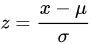


The sample formula is:

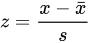


Our variables swapped in gives:

$$Z = \frac{Y - \mu_Y}{\sigma_Y}$$

Our values plugged in for $Y$ = 90:

$$Z = \frac{90 - 100}{10} = -1$$

-1 is 1 standard deviation below the average

Find the  area to the left of $Z$ on the standard normal curve
$$\mathbb{P}(Y < 90) \approx \mathbb{P}(Z < -1) = \Phi(-1) = 0.15866 \approx 15.87\% $$

Personal notes

the Poisson distribution models rare, random counts occurring at a constant rate. Mathematically, deriving its mean $\sum x \cdot P(X=x)$ and variance using its probability mass function $P(X=k) = \frac{\lambda^k e^{-\lambda}}{k!}$ leads directly to $\lambda$ in both cases


The mean and variance are just n$\lambda$, since the 
$\mathbb{E}(Y)$ = $\mathbb{V}(Y)$ = n$\lambda$